## LIBRERIA

In [21]:
!conda install -y pyarrow
! pip install pyreadr
from sqlalchemy import create_engine
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import mapclassify 
import matplotlib.patheffects as pe
from matplotlib.lines import Line2D
import numpy as np
import pyreadr

Jupyter detected...
3 channel Terms of Service accepted
Channels:
 - defaults
Platform: win-64
Solving environment: done

# All requested packages already installed.





==> WARNING: A newer version of conda exists. <==
    current version: 26.1.1
    latest version: 26.5.3

Please update conda by running

    $ conda update -n base -c defaults conda




## ESTUDIO VARIABLES 2017

## 1.CONEXIÓN BASE DE DATOS

In [22]:
DB_HOST = 'localhost'
DB_PORT = 5432
DB_NAME = 'censo_2017'
DB_USER = 'postgres'
DB_PASSWORD = 'postgres' 

engine = create_engine(
    f'postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}')

## 2.CARGAR DATOS

In [23]:
sql_comunas = '''
SELECT nom_comuna, geom
FROM dpa.comunas_rm_shp;
'''

gdf_comunas    = gpd.read_postgis(sql_comunas, engine, geom_col='geom')
gdf_centroides = gdf_comunas.copy()
gdf_centroides['geometry'] = gdf_comunas.centroid

print(f'Comunas: {len(gdf_comunas)}')
display(gdf_comunas)

Comunas: 52


,nom_comuna,geom
0,LO PRADO,"MULTIPOLYGON (((339891.406 6298725.5, 339967.9..."
1,INDEPENDENCIA,"MULTIPOLYGON (((345568.713 6303028.6, 345794.7..."
2,LO ESPEJO,"MULTIPOLYGON (((344800.111 6290835.676, 343521..."
3,SAN RAMÓN,"MULTIPOLYGON (((348001.245 6290000.561, 348259..."
4,LA CISTERNA,"MULTIPOLYGON (((346490 6286649.498, 345256.375..."
5,PEDRO AGUIRRE CERDA,"MULTIPOLYGON (((344800.111 6290835.676, 342530..."
6,SAN MIGUEL,"MULTIPOLYGON (((348011.801 6290001.611, 348001..."
7,CONCHALÍ,"MULTIPOLYGON (((342803.041 6306876.533, 343470..."
8,SAN JOAQUÍN,"MULTIPOLYGON (((349191.057 6294882.314, 349437..."
9,LA GRANJA,"MULTIPOLYGON (((350573.769 6287953.638, 350492..."


## 3.INDICADORES

In [24]:
sql_indicadores = '''
WITH agg AS 
(
SELECT c.nom_comuna, 
z.geocodigo::DOUBLE PRECISION AS geocodigo, 
ROUND (((COUNT(*) FILTER (WHERE UPPER(p.p18) IN ('A', 'B')))*100.0/COUNT(*)),2) AS sector_primario,
ROUND (((COUNT(*) FILTER (WHERE p.p15 = 12))*100.0/COUNT(*)),2) AS porcentaje_profesionales
FROM public.personas AS p
JOIN public.hogares AS h
ON p.hogar_ref_id = h.hogar_ref_id
JOIN public.viviendas AS v
ON h.vivienda_ref_id = v.vivienda_ref_id
JOIN public.zonas AS z
ON v.zonaloc_ref_id = z.zonaloc_ref_id
JOIN public.comunas AS c
ON z.codigo_comuna = c.codigo_comuna
JOIN public.provincias AS pr 
ON pr.provincia_ref_id = c.provincia_ref_id
WHERE pr.nom_provincia = 'MELIPILLA'
GROUP BY c.nom_comuna, z.geocodigo
)
SELECT a.*, shp.geom
FROM agg AS a
JOIN dpa.zonas_censales_rm AS shp
ON shp.geocodigo = a.geocodigo;
'''

In [25]:
gdf = gpd.read_postgis(sql_indicadores, engine, geom_col='geom')

In [26]:
gdf

,nom_comuna,geocodigo,sector_primario,porcentaje_profesionales,geom
0,ALHUÉ,1.350201e+10,18.37,9.35,"MULTIPOLYGON (((306250.709 6232826.305, 306344..."
1,ALHUÉ,1.350201e+10,14.58,0.00,"MULTIPOLYGON (((304044.672 6232382.536, 304070..."
2,ALHUÉ,1.350202e+10,34.98,3.67,"MULTIPOLYGON (((295472.326 6234041.035, 295780..."
3,ALHUÉ,1.350202e+10,45.07,14.08,"MULTIPOLYGON (((291374.242 6233598.206, 291459..."
4,ALHUÉ,1.350203e+10,16.65,5.22,"MULTIPOLYGON (((311500.554 6233729.707, 311534..."
...,...,...,...,...,...
219,SAN PEDRO,1.350506e+10,19.27,6.42,"MULTIPOLYGON (((270726.55 6239669.063, 270758...."
220,SAN PEDRO,1.350506e+10,17.96,5.83,"MULTIPOLYGON (((263857.95 6238016.555, 264500...."
221,SAN PEDRO,1.350506e+10,19.80,2.48,"MULTIPOLYGON (((266072.646 6242106.632, 266163..."
222,SAN PEDRO,1.350506e+10,20.69,1.38,"MULTIPOLYGON (((263628.433 6239389.385, 263669..."


## 4.EDA

In [27]:
gdf[['sector_primario','porcentaje_profesionales']].describe().round(2)

,sector_primario,porcentaje_profesionales
count,224.00,224.00
mean,13.69,9.19
std,9.49,7.50
min,0.00,0.00
25%,6.49,4.40
50%,12.50,7.09
75%,18.39,11.34
max,75.00,41.10


## 5.MAPA

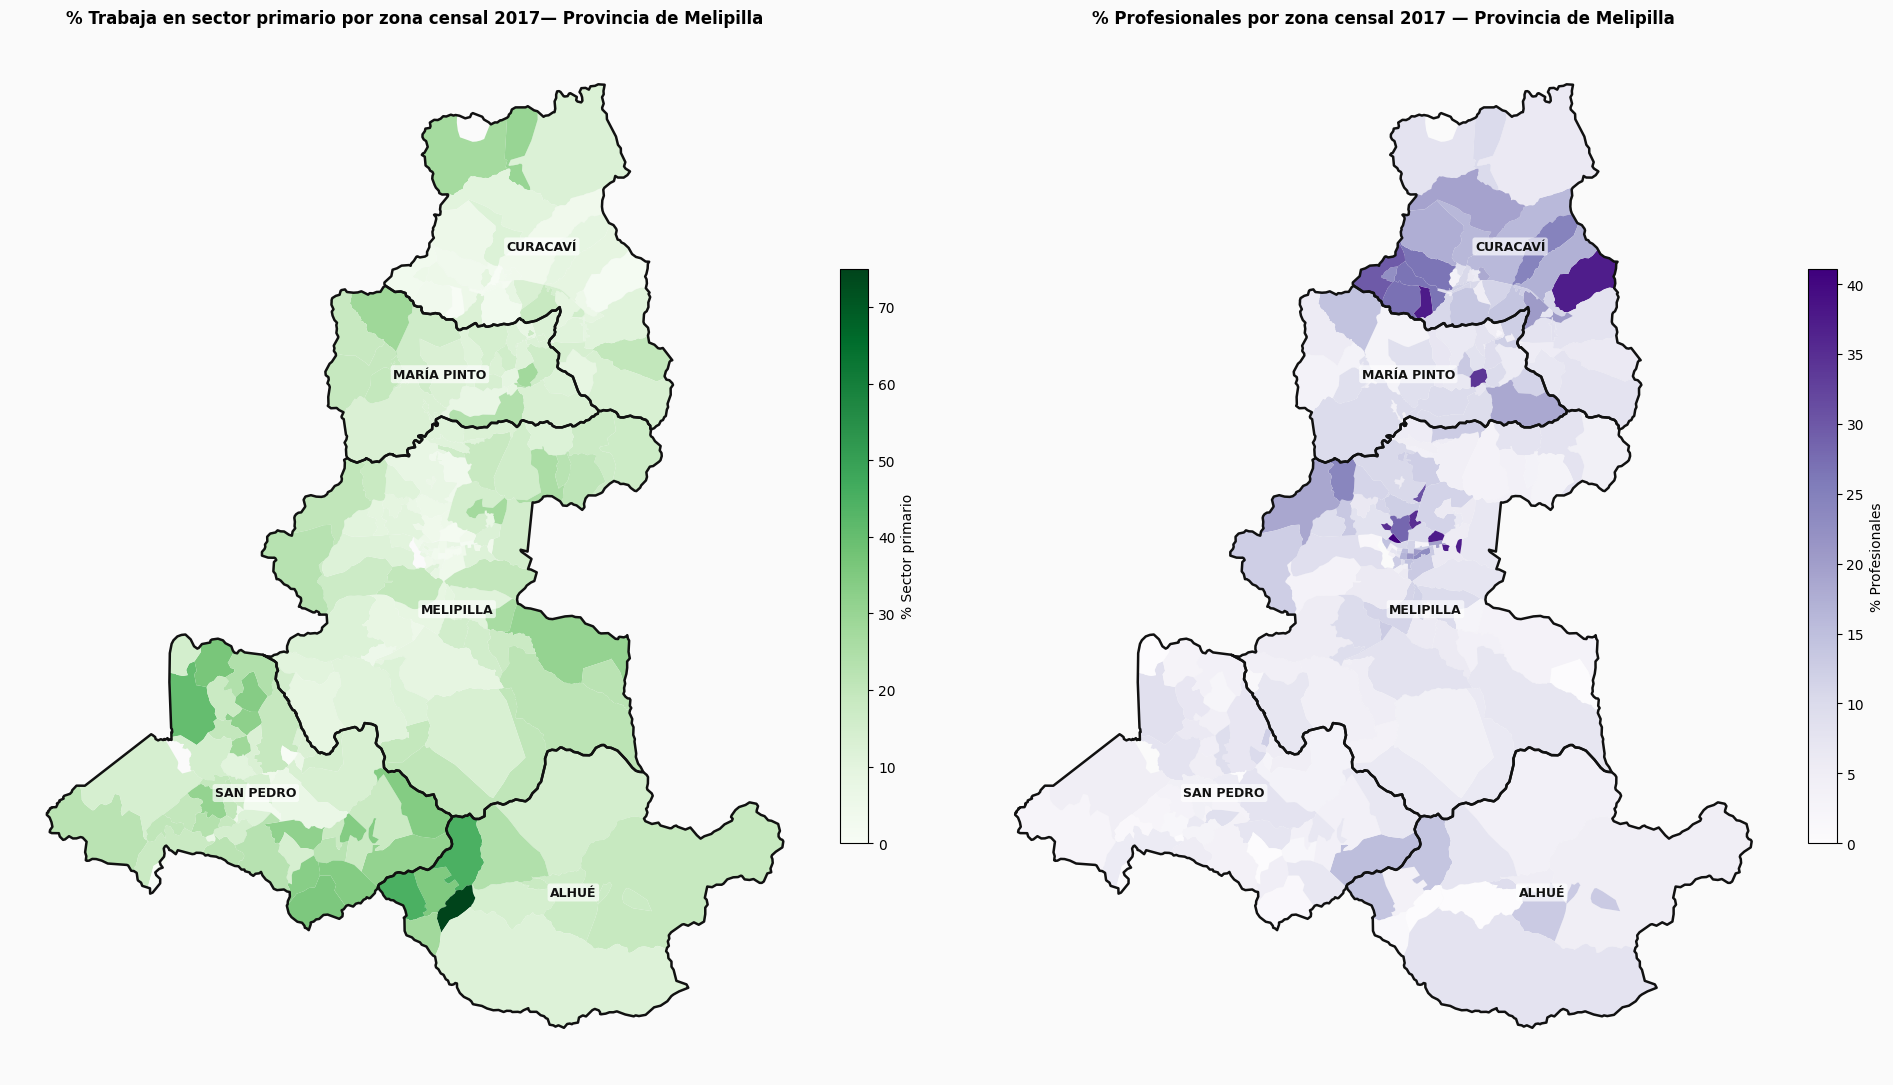

In [28]:
def plot_univariado(ax, gdf_z, gdf_c, gdf_ct, col, cmap, titulo, cbar_label):
    gdf_z.plot(
        column=col, ax=ax, cmap=cmap, linewidth=0,
        legend=True,
        legend_kwds={'label': cbar_label, 'shrink': 0.55, 'pad': 0.02}
    )
    gdf_c.plot(ax=ax, facecolor='none', edgecolor='#111', linewidth=1.8)
    for _, row in gdf_ct.iterrows():
        ax.annotate(
            row['nom_comuna'],
            xy=(row.geometry.x, row.geometry.y),
            ha='center', va='center',
            fontsize=9, fontweight='bold', color='#111',
            bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.65, ec='none')
        )
    ax.set_title(titulo, fontsize=12, fontweight='bold', pad=10)
    ax.axis('off')

comunas_melipilla = ['MELIPILLA', 'MARÍA PINTO', 'CURACAVÍ', 'ALHUÉ', 'SAN PEDRO']

gdf_comunas_mel = gdf_comunas[gdf_comunas['nom_comuna'].str.upper().isin(comunas_melipilla)]
gdf_centroides_mel = gdf_centroides[gdf_centroides['nom_comuna'].str.upper().isin(comunas_melipilla)]

gdf_mel = gdf[gdf['nom_comuna'].str.upper().isin(comunas_melipilla)]

fig, axes = plt.subplots(1, 2, figsize=(20, 11))
fig.patch.set_facecolor('#fafafa')

plot_univariado(
    axes[0], gdf_mel, gdf_comunas_mel, gdf_centroides_mel,
    'sector_primario', 'Greens',
    '% Trabaja en sector primario por zona censal 2017— Provincia de Melipilla',
    '% Sector primario'
)

plot_univariado(
    axes[1], gdf_mel, gdf_comunas_mel, gdf_centroides_mel,
    'porcentaje_profesionales', 'Purples',
    '% Profesionales por zona censal 2017 — Provincia de Melipilla',
    '% Profesionales'
)

plt.tight_layout(pad=2)
plt.show()

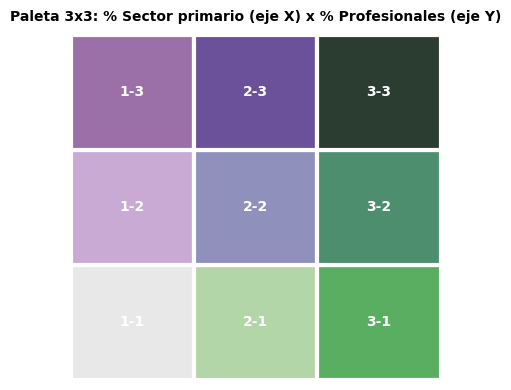

In [29]:
BIVARIATE_COLORS = {
    '1-1': '#e8e8e8',  # bajo-bajo   → neutro claro
    '2-1': '#b2d6a7',  # medio-bajo  → verde claro
    '3-1': '#5aae61',  # alto-bajo   → verde pleno
    '1-2': '#c8aad4',  # bajo-medio  → morado claro
    '2-2': '#9090bc',  # medio-medio → pizarra azul
    '3-2': '#4d8e6e',  # alto-medio  → verde-azul oscuro
    '1-3': '#9b6fa8',  # bajo-alto   → morado pleno
    '2-3': '#6b509a',  # medio-alto  → morado profundo
    '3-3': '#2b3d30',  # alto-alto   → verde muy oscuro
}

# Visualizar la paleta como grilla
fig_pal, ax_pal = plt.subplots(figsize=(4, 4))
for key, color in BIVARIATE_COLORS.items():
    i, j = map(int, key.split('-'))
    ax_pal.add_patch(plt.Rectangle(
        ((i - 1) / 3, (j - 1) / 3), 1/3, 1/3,
        transform=ax_pal.transAxes,
        facecolor=color, edgecolor='white', linewidth=3, clip_on=False
    ))
    ax_pal.text(
        (i - 0.5) / 3, (j - 0.5) / 3, key,
        ha='center', va='center', fontsize=10, color='white',
        fontweight='bold', transform=ax_pal.transAxes
    )
ax_pal.set_xlim(0, 1)
ax_pal.set_ylim(0, 1)
ax_pal.axis('off')
ax_pal.set_title('Paleta 3x3: % Sector primario (eje X) x % Profesionales (eje Y)',
                 fontsize=10, fontweight='bold', pad=10)
plt.tight_layout()
plt.show()

In [30]:
cls_x = mapclassify.FisherJenks(gdf['sector_primario'].values,    k=3)
cls_y = mapclassify.FisherJenks(gdf['porcentaje_profesionales'].values, k=3)

gdf_bi = gdf.copy()
gdf_bi['class_x']  = cls_x.yb + 1 
gdf_bi['class_y']  = cls_y.yb + 1
gdf_bi['bi_class'] = gdf_bi['class_x'].astype(str) + '-' + gdf_bi['class_y'].astype(str)
gdf_bi['color']    = gdf_bi['bi_class'].map(BIVARIATE_COLORS)

print('Cortes Jenks — % Migrantes:')
print([round(b, 2) for b in cls_x.bins])
print('\nCortes Jenks — % Escolaridad >= 16:')
print([round(b, 2) for b in cls_y.bins])
print(f'\nDistribucion de clases bivariadas:')
print(gdf_bi['bi_class'].value_counts().sort_index())

sin_color = gdf_bi[gdf_bi['color'].isna()]
if len(sin_color) == 0:
    print('\nTodas las zonas tienen color asignado')
else:
    print(f'\nAtencion: {len(sin_color)} zonas sin color: {sin_color["bi_class"].unique()}')

Cortes Jenks — % Migrantes:
[np.float64(11.15), np.float64(24.2), np.float64(75.0)]

Cortes Jenks — % Escolaridad >= 16:
[np.float64(8.79), np.float64(21.33), np.float64(41.1)]

Distribucion de clases bivariadas:
bi_class
1-1    39
1-2    42
1-3    15
2-1    83
2-2    21
2-3     1
3-1    18
3-2     5
Name: count, dtype: int64

Todas las zonas tienen color asignado


C:\Users\DIGEA\anaconda3\envs\idg\Lib\site-packages\IPython\core\interactiveshell.py:3747: UserWarning: Numba not installed. Using slow pure python version.
  exec(code_obj, self.user_global_ns, self.user_ns)


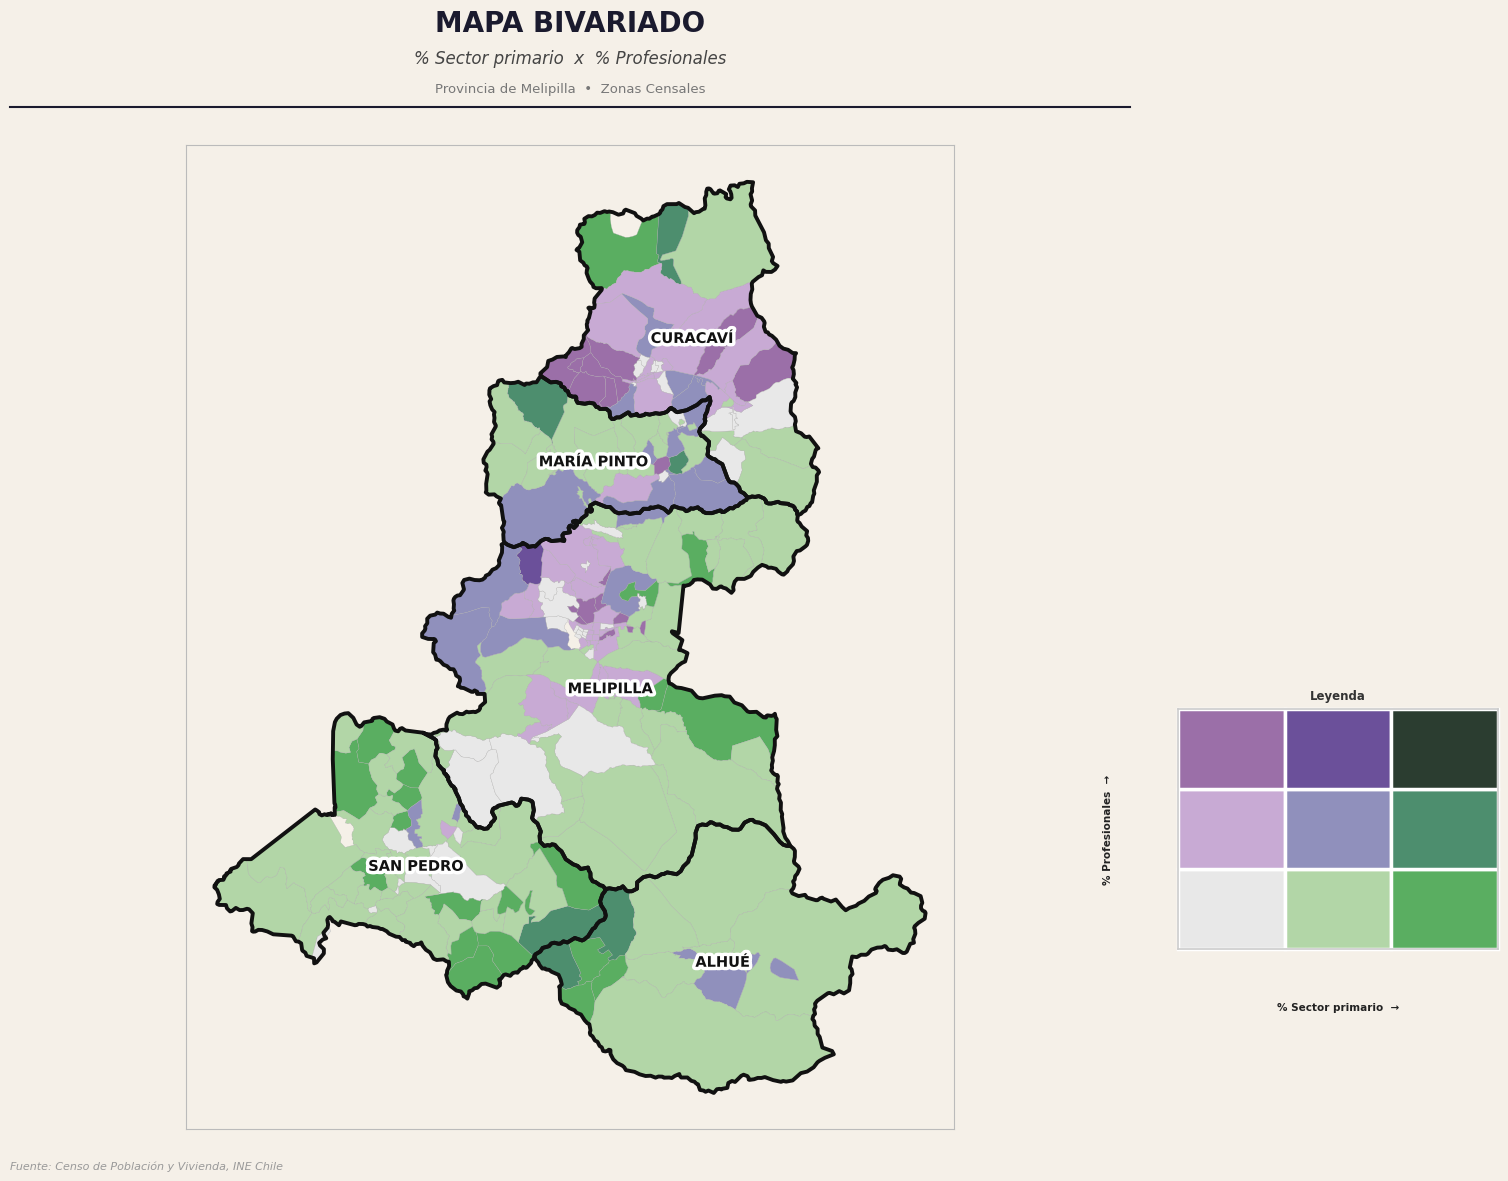

In [31]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.patheffects as pe

# 1. Definir y filtrar las comunas de Melipilla
comunas_mel = ['MELIPILLA', 'MARÍA PINTO', 'CURACAVÍ', 'ALHUÉ', 'SAN PEDRO']

gdf_bi_mel = gdf_bi[gdf_bi['nom_comuna'].str.upper().isin(comunas_mel)]
gdf_comunas_mel = gdf_comunas[gdf_comunas['nom_comuna'].str.upper().isin(comunas_mel)]
gdf_centroides_mel = gdf_centroides[gdf_centroides['nom_comuna'].str.upper().isin(comunas_mel)]

# 2. Función para la leyenda bivariada
def crear_leyenda_bivariada(ax, colores, xlab, ylab, dim=3):
    for i in range(1, dim + 1):
        for j in range(1, dim + 1):
            ax.add_patch(plt.Rectangle(
                ((i - 1) / dim, (j - 1) / dim),
                1 / dim, 1 / dim,
                transform=ax.transAxes,
                facecolor=colores[f'{i}-{j}'],
                edgecolor='white',
                linewidth=2.5,
                clip_on=False
            ))
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.text(0.5, -0.22, xlab,
            ha='center', va='top', fontsize=7.5, transform=ax.transAxes,
            color='#222', fontweight='bold', clip_on=False)
    ax.text(-0.22, 0.5, ylab,
            ha='center', va='center', fontsize=7.5, transform=ax.transAxes,
            rotation=90, color='#222', fontweight='bold', clip_on=False)

# ── Figura y layout ───────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 12))
fig.patch.set_facecolor('#f5f0e8')      # fondo general

ax_map = fig.add_axes([0.02, 0.05, 0.70, 0.82])   # mapa
ax_leg = fig.add_axes([0.75, 0.20, 0.20, 0.20])   # leyenda

# ── Mapa ─────────────────────────────────────────────────────────────────────
# Dejamos transparente o del mismo color del fondo general para no simular mar/fondo gigante
ax_map.set_facecolor('#f5f0e8') 

# Zonas censales filtradas
gdf_bi_mel.plot(
    color=gdf_bi_mel['color'].tolist(), ax=ax_map,
    linewidth=0.2, edgecolor='#aaaaaa', zorder=2
)

# Límites comunales de Melipilla
gdf_comunas_mel.plot(
    ax=ax_map, facecolor='none', edgecolor='#111111',
    linewidth=2.8, zorder=4
)

# Etiquetas con stroke blanco 
for _, row in gdf_centroides_mel.iterrows():
    txt = ax_map.annotate(
        row['nom_comuna'],
        xy=(row.geometry.x, row.geometry.y),
        ha='center', va='center',
        fontsize=10.5, fontweight='bold', color='#111111', zorder=6
    )
    txt.set_path_effects([pe.withStroke(linewidth=5, foreground='white')])

# ── ENCUADRE / ZOOM ESTRICTO EN MELIPILLA ────────────────────────────────────
minx, miny, maxx, maxy = gdf_comunas_mel.total_bounds
margin_x = (maxx - minx) * 0.04
margin_y = (maxy - miny) * 0.04

ax_map.set_xlim(minx - margin_x, maxx + margin_x)
ax_map.set_ylim(miny - margin_y, maxy + margin_y)

# Marco del mapa
for spine in ax_map.spines.values():
    spine.set_visible(True)
    spine.set_color('#bbbbbb')
    spine.set_linewidth(0.8)
ax_map.set_xticks([])
ax_map.set_yticks([])

# ── Bloque de títulos ────────────────────────────────────────────────────────
fig.text(0.37, 0.965, 'MAPA BIVARIADO', ha='center',
         fontsize=20, fontweight='bold', color='#1a1a2e')
fig.text(0.37, 0.938, '% Sector primario  x  % Profesionales', ha='center',
         fontsize=12, color='#444', style='italic')
fig.text(0.37, 0.914, 'Provincia de Melipilla  •  Zonas Censales',
         ha='center', fontsize=9.5, color='#777')

# Línea separadora
fig.add_artist(Line2D([0.02, 0.72], [0.902, 0.902],
                      transform=fig.transFigure,
                      color='#1a1a2e', linewidth=1.5))

# Fuente
fig.text(0.02, 0.017, 'Fuente: Censo de Población y Vivienda, INE Chile',
         ha='left', fontsize=8, color='#999', style='italic')

# ── Leyenda bivariada ────────────────────────────────────────────────────────
ax_leg.set_facecolor('white')
for spine in ax_leg.spines.values():
    spine.set_visible(True)
    spine.set_color('#cccccc')
    spine.set_linewidth(1.2)

crear_leyenda_bivariada(
    ax_leg, BIVARIATE_COLORS,
    xlab='% Sector primario  →',
    ylab='% Profesionales  →'
)
ax_leg.set_title('Leyenda', fontsize=8.5, fontweight='bold', pad=7, color='#333')

plt.show()

## 6.GRAFICO

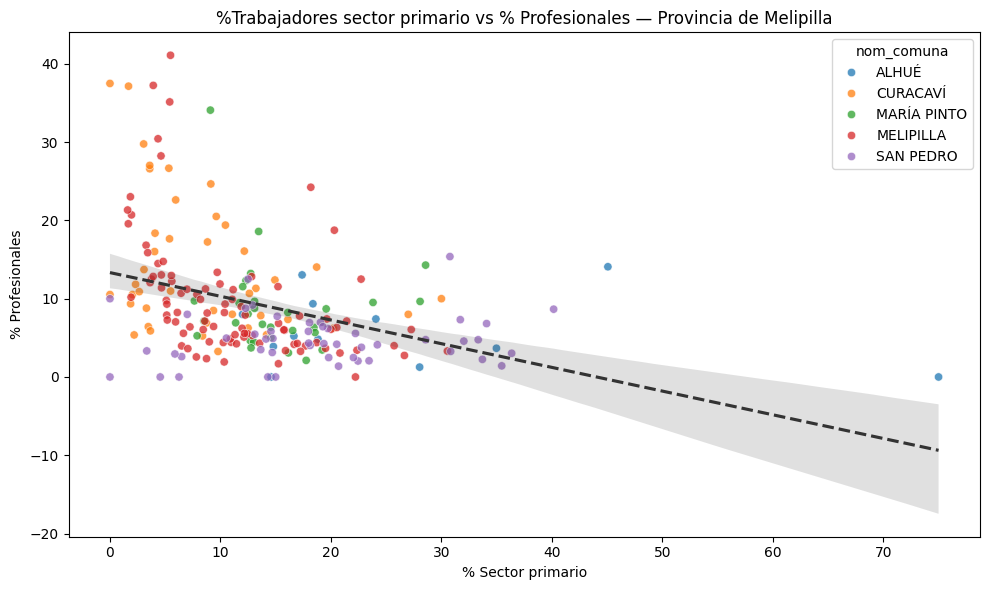

In [32]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.scatterplot(data=gdf, x='sector_primario', y='porcentaje_profesionales',
                hue='nom_comuna', alpha=0.75, ax=ax)

sns.regplot(data=gdf, x='sector_primario', y='porcentaje_profesionales',
            scatter=False, color='#333', line_kws={'ls': '--'}, ax=ax)

ax.set(xlabel='% Sector primario', ylabel='% Profesionales',
       title='%Trabajadores sector primario vs % Profesionales — Provincia de Melipilla')
plt.tight_layout()
plt.show()

## ESTUDIO VARIABLES 2024

## 1.CONEXIÓN BASE DE DATOS

In [33]:
RUTA_CENSO_ZONAL = "../Parquet/Cartografía_censo2024_R13_Zonal.parquet"

In [34]:
censo_zonal = gpd.read_parquet(RUTA_CENSO_ZONAL)

## 2.INDICADORES

In [35]:
# Buscamos las variables de interés

for col in sorted(censo_zonal.columns):
    print(col)

AREA_C
CATEGORIA
COD_CATEGORIA
COD_DISTRITO
COD_ENTIDAD
COD_LOCALIDAD
COD_PROVINCIA
COD_REGION
COD_ZONA
COMUNA
CUT
DISTRITO
ENTIDAD
ID_DISTRITO
ID_ENTIDAD
ID_LOCALIDAD
ID_ZONA
LOCALIDAD
OBJECTID
PROVINCIA
REGION
SHAPE
SHAPE_Area
SHAPE_Length
n_afrodescendencia
n_analfabet
n_asistencia_basica
n_asistencia_media
n_asistencia_parv
n_asistencia_superior
n_basura_entierra
n_basura_eriazo
n_basura_otro
n_basura_rio
n_basura_servicios
n_caenes_A
n_caenes_B
n_caenes_C
n_caenes_D
n_caenes_E
n_caenes_F
n_caenes_G
n_caenes_H
n_caenes_I
n_caenes_J
n_caenes_K
n_caenes_L
n_caenes_M
n_caenes_N
n_caenes_O
n_caenes_P
n_caenes_Q
n_caenes_R
n_caenes_S
n_caenes_T
n_caenes_U
n_cine_especial_diferencial
n_cine_nunca_curso_primera_infancia
n_cine_primaria
n_cine_secundaria
n_cine_terciaria_maestria_doctorado
n_cise_rec_dependientes
n_cise_rec_independientes
n_cise_rec_trabajador_no_remunerado
n_ciuo_0
n_ciuo_1
n_ciuo_2
n_ciuo_3
n_ciuo_4
n_ciuo_5
n_ciuo_6
n_ciuo_7
n_ciuo_8
n_ciuo_9
n_comb_calefaccion_carbon
n

In [50]:
# No está la comuna de San pedro

print(censo_zonal['COMUNA'].unique())

<ArrowStringArray>
[               'BUIN',               'PAINE',          'HUECHURABA',
              'COLINA',               'LAMPA',              'TILTIL',
            'CONCHALÍ',       'INDEPENDENCIA',            'RECOLETA',
          'LA PINTANA',         'PUENTE ALTO',    'ESTACIÓN CENTRAL',
            'LO PRADO',           'LO ESPEJO', 'PEDRO AGUIRRE CERDA',
        'SAN BERNARDO',     'CALERA DE TANGO',           'EL BOSQUE',
         'LA CISTERNA',          'LA FLORIDA',           'PEÑALOLÉN',
            'LA REINA',          'LAS CONDES',        'LO BARNECHEA',
            'VITACURA',         'CERRO NAVIA',       'QUINTA NORMAL',
           'CERRILLOS',               'MAIPÚ',            'PUDAHUEL',
           'MELIPILLA',       'ISLA DE MAIPO',       'PADRE HURTADO',
            'PEÑAFLOR',               'MACUL',               'ÑUÑOA',
           'QUILICURA',               'RENCA',              'PIRQUE',
   'SAN JOSÉ DE MAIPO',         'SAN JOAQUÍN',          'SAN MIGUEL',
 

In [51]:
# Filtrar por la Provincia de Melipilla
comunas_melipilla = ['MELIPILLA', 'MARÍA PINTO', 'CURACAVÍ', 'ALHUÉ']
gdf_mel_2024 = censo_zonal[censo_zonal['COMUNA'].str.upper().isin(comunas_melipilla)].copy()

# Calcular el sector primario (sumando A y B, dividido por ocupados)
suma_primario = gdf_mel_2024['n_caenes_A'] + gdf_mel_2024['n_caenes_B']
gdf_mel_2024['sector_primario2'] = (suma_primario / gdf_mel_2024['n_per']).fillna(0) * 100

# Calcular los profesionales (dividido por el total de personas)
gdf_mel_2024['porcentaje_profesionales2'] = (gdf_mel_2024['n_cine_terciaria_maestria_doctorado'] / gdf_mel_2024['n_per']).fillna(0) * 100

In [52]:
# Seleccionar las columnas usando el nombre real de la zona (ID_ZONA)
tabla_resultados = gdf_mel_2024[['COMUNA', 'ID_ZONA', 'sector_primario2', 'porcentaje_profesionales2']].copy()

#. Redondear los porcentajes a 2 decimales para mayor claridad
tabla_resultados['%_sector_primario2'] = tabla_resultados['sector_primario2'].round(2)
tabla_resultados['%_porcentaje_profesionales2'] = tabla_resultados['porcentaje_profesionales2'].round(2)

# Ordenar alfabéticamente por comuna y numéricamente por ID_ZONA
tabla_resultados = tabla_resultados.sort_values(by=['COMUNA', 'ID_ZONA'])

# Mostrar la tabla resultante
display(tabla_resultados)

,COMUNA,ID_ZONA,sector_primario2,porcentaje_profesionales2,%_sector_primario2,%_porcentaje_profesionales2
1848,ALHUÉ,1.350201e+09,13.316936,19.325369,13.32,19.33
1849,ALHUÉ,1.350203e+09,13.882163,13.962873,13.88,13.96
1850,CURACAVÍ,1.350301e+09,3.104787,14.445882,3.10,14.45
1853,CURACAVÍ,1.350301e+09,3.139584,22.528638,3.14,22.53
1851,CURACAVÍ,1.350301e+09,3.017586,12.949640,3.02,12.95
1852,CURACAVÍ,1.350306e+09,2.303961,19.967664,2.30,19.97
1854,CURACAVÍ,1.350306e+09,2.912341,21.337947,2.91,21.34
1855,CURACAVÍ,1.350307e+09,9.741551,16.103380,9.74,16.10
1856,MARÍA PINTO,1.350401e+09,8.624230,14.014374,8.62,14.01
1858,MARÍA PINTO,1.350402e+09,10.198020,3.861386,10.20,3.86


## 3.EDA

In [53]:
gdf_mel_2024[['sector_primario2', 'porcentaje_profesionales2']].describe().round(2)

,sector_primario2,porcentaje_profesionales2
count,42.00,42.00
mean,7.77,15.76
std,4.15,7.56
min,1.34,3.86
25%,3.87,10.98
50%,7.78,13.99
75%,10.19,19.50
max,16.43,35.97


## 4.MAPA

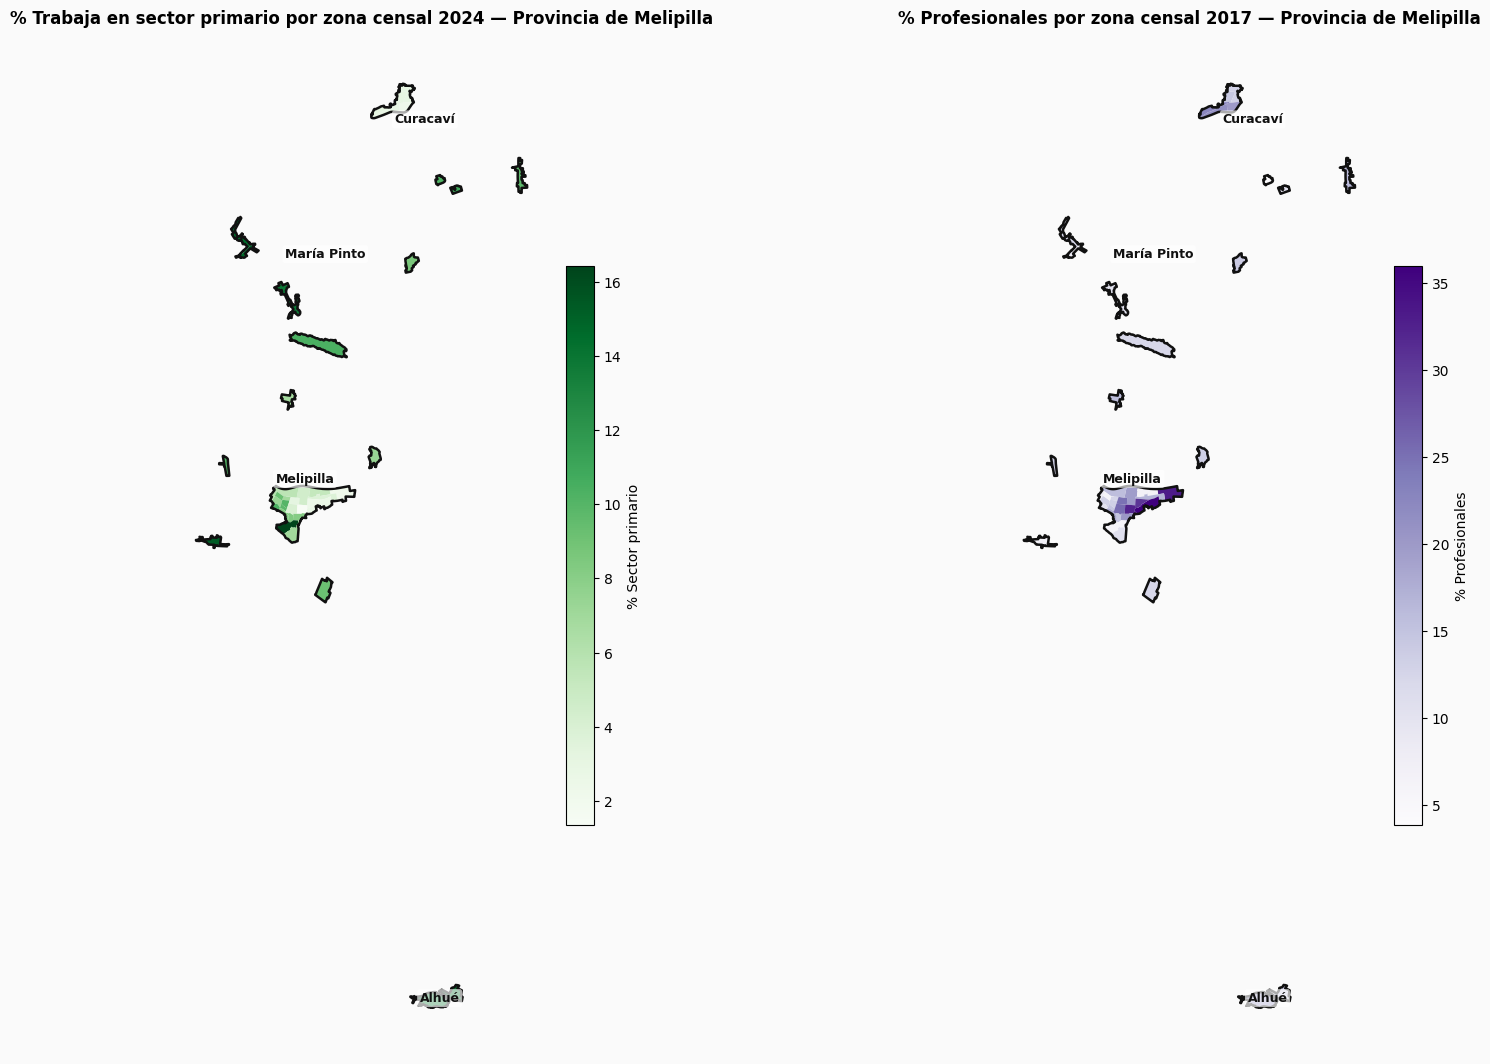

In [54]:
import matplotlib.pyplot as plt

# 1. Definir la función adaptada al 2024
def plot_univariado_2024(ax, gdf_z, gdf_c, gdf_ct, col, cmap, titulo, cbar_label):
    gdf_z.plot(
        column=col, ax=ax, cmap=cmap, linewidth=0,
        legend=True,
        legend_kwds={'label': cbar_label, 'shrink': 0.55, 'pad': 0.02}
    )
    gdf_c.plot(ax=ax, facecolor='none', edgecolor='#111', linewidth=1.8)
    
    for _, row in gdf_ct.iterrows():
        ax.annotate(
            row['COMUNA'].title(), 
            xy=(row.geometry.x, row.geometry.y),
            ha='center', va='center',
            fontsize=9, fontweight='bold', color='#111',
            bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.65, ec='none')
        )
    ax.set_title(titulo, fontsize=12, fontweight='bold', pad=10)
    ax.axis('off')

# 2. Generar capas de comunas
gdf_comunas_mel = gdf_mel_2024.dissolve(by='COMUNA').reset_index()

# Calculamos los centroides sin la advertencia: 
# Transformamos a metros (EPSG 3857), sacamos el centroide y volvemos al sistema original
gdf_centroides_mel = gdf_comunas_mel.copy()
gdf_centroides_mel['geometry'] = gdf_comunas_mel.to_crs(epsg=3857).centroid.to_crs(gdf_comunas_mel.crs)

# 3. Crear la figura y los mapas
fig, axes = plt.subplots(1, 2, figsize=(20, 11))
fig.patch.set_facecolor('#fafafa')

# Mapa 1: Sector Primario 2024
plot_univariado_2024(
    axes[0], gdf_mel_2024, gdf_comunas_mel, gdf_centroides_mel,
    'sector_primario2', 'Greens',
    '% Trabaja en sector primario por zona censal 2024 — Provincia de Melipilla',
    '% Sector primario'
)

# Mapa 2: Profesionales 2024
plot_univariado_2024(
    axes[1], gdf_mel_2024, gdf_comunas_mel, gdf_centroides_mel,
    'porcentaje_profesionales2', 'Purples',
    '% Profesionales por zona censal 2017 — Provincia de Melipilla',
    '% Profesionales'
)

plt.tight_layout(pad=2)
plt.show()

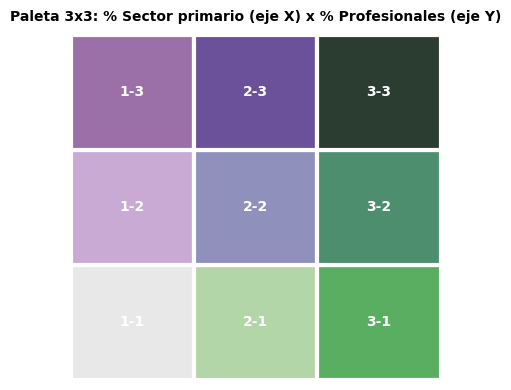

In [55]:
BIVARIATE_COLORS = {
    '1-1': '#e8e8e8',  # bajo-bajo   → neutro claro
    '2-1': '#b2d6a7',  # medio-bajo  → verde claro
    '3-1': '#5aae61',  # alto-bajo   → verde pleno
    '1-2': '#c8aad4',  # bajo-medio  → morado claro
    '2-2': '#9090bc',  # medio-medio → pizarra azul
    '3-2': '#4d8e6e',  # alto-medio  → verde-azul oscuro
    '1-3': '#9b6fa8',  # bajo-alto   → morado pleno
    '2-3': '#6b509a',  # medio-alto  → morado profundo
    '3-3': '#2b3d30',  # alto-alto   → verde muy oscuro
}

# Visualizar la paleta como grilla
fig_pal, ax_pal = plt.subplots(figsize=(4, 4))
for key, color in BIVARIATE_COLORS.items():
    i, j = map(int, key.split('-'))
    ax_pal.add_patch(plt.Rectangle(
        ((i - 1) / 3, (j - 1) / 3), 1/3, 1/3,
        transform=ax_pal.transAxes,
        facecolor=color, edgecolor='white', linewidth=3, clip_on=False
    ))
    ax_pal.text(
        (i - 0.5) / 3, (j - 0.5) / 3, key,
        ha='center', va='center', fontsize=10, color='white',
        fontweight='bold', transform=ax_pal.transAxes
    )
ax_pal.set_xlim(0, 1)
ax_pal.set_ylim(0, 1)
ax_pal.axis('off')
ax_pal.set_title('Paleta 3x3: % Sector primario (eje X) x % Profesionales (eje Y)',
                 fontsize=10, fontweight='bold', pad=10)
plt.tight_layout()
plt.show()

In [56]:
# 1. Calcular los cortes de Fisher-Jenks usando la tabla correcta: gdf_mel_2024
cls_x = mapclassify.FisherJenks(gdf_mel_2024['sector_primario2'].values, k=3)
cls_y = mapclassify.FisherJenks(gdf_mel_2024['porcentaje_profesionales2'].values, k=3)

# 2. Copiar la tabla para crear las clases bivariadas
gdf_bi = gdf_mel_2024.copy()
gdf_bi['class_x']  = cls_x.yb + 1 
gdf_bi['class_y']  = cls_y.yb + 1
gdf_bi['bi_class'] = gdf_bi['class_x'].astype(str) + '-' + gdf_bi['class_y'].astype(str)
gdf_bi['color']    = gdf_bi['bi_class'].map(BIVARIATE_COLORS)

# 3. Imprimir los resultados (textos actualizados)
print('Cortes Jenks — % Sector Primario (2024):')
print([round(b, 2) for b in cls_x.bins])

print('\nCortes Jenks — % Profesionales (2024):')
print([round(b, 2) for b in cls_y.bins])

print(f'\nDistribución de clases bivariadas:')
print(gdf_bi['bi_class'].value_counts().sort_index())

# 4. Verificar si quedaron zonas sin color
sin_color = gdf_bi[gdf_bi['color'].isna()]
if len(sin_color) == 0:
    print('\nTodas las zonas tienen color asignado')
else:
    print(f'\nAtención: {len(sin_color)} zonas sin color: {sin_color["bi_class"].unique()}')

Cortes Jenks — % Sector Primario (2024):
[np.float64(5.99), np.float64(11.06), np.float64(16.43)]

Cortes Jenks — % Profesionales (2024):
[np.float64(13.45), np.float64(22.53), np.float64(35.97)]

Distribución de clases bivariadas:
bi_class
1-1     3
1-2     7
1-3     6
2-1    12
2-2     7
3-1     5
3-2     2
Name: count, dtype: int64

Todas las zonas tienen color asignado


C:\Users\DIGEA\anaconda3\envs\idg\Lib\site-packages\IPython\core\interactiveshell.py:3747: UserWarning: Numba not installed. Using slow pure python version.
  exec(code_obj, self.user_global_ns, self.user_ns)


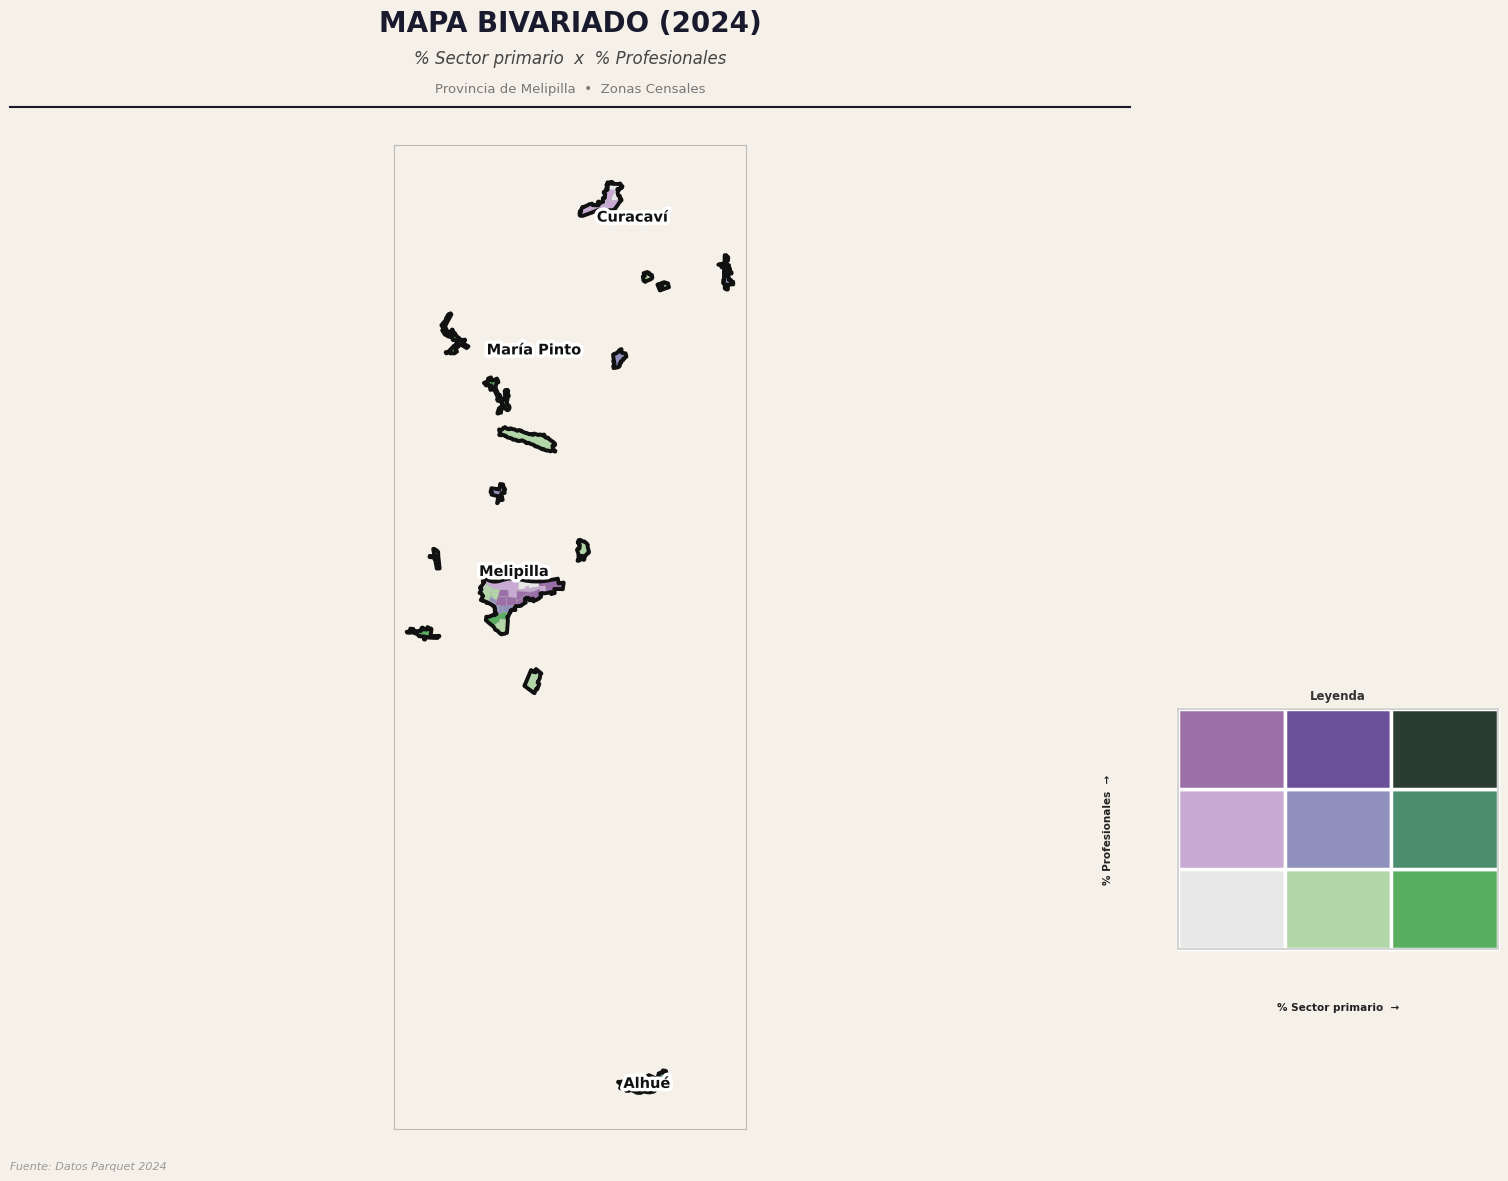

In [57]:
# 1. Preparar las capas desde tu tabla bivariada del 2024 (gdf_bi)
# Como gdf_bi ya se creó filtrando Melipilla, la usamos directamente
gdf_bi_mel = gdf_bi.copy()

# Crear bordes comunales disolviendo las zonas de gdf_bi_mel
gdf_comunas_mel = gdf_bi_mel.dissolve(by='COMUNA').reset_index()

# Calcular centroides (pasando a metros temporalmente para evitar el warning)
gdf_centroides_mel = gdf_comunas_mel.copy()
gdf_centroides_mel['geometry'] = gdf_comunas_mel.to_crs(epsg=3857).centroid.to_crs(gdf_comunas_mel.crs)

# 2. Función para la leyenda bivariada
def crear_leyenda_bivariada(ax, colores, xlab, ylab, dim=3):
    for i in range(1, dim + 1):
        for j in range(1, dim + 1):
            ax.add_patch(plt.Rectangle(
                ((i - 1) / dim, (j - 1) / dim),
                1 / dim, 1 / dim,
                transform=ax.transAxes,
                facecolor=colores[f'{i}-{j}'],
                edgecolor='white',
                linewidth=2.5,
                clip_on=False
            ))
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.text(0.5, -0.22, xlab,
            ha='center', va='top', fontsize=7.5, transform=ax.transAxes,
            color='#222', fontweight='bold', clip_on=False)
    ax.text(-0.22, 0.5, ylab,
            ha='center', va='center', fontsize=7.5, transform=ax.transAxes,
            rotation=90, color='#222', fontweight='bold', clip_on=False)

# ── Figura y layout ───────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 12))
fig.patch.set_facecolor('#f5f0e8')      # fondo general

ax_map = fig.add_axes([0.02, 0.05, 0.70, 0.82])   # mapa
ax_leg = fig.add_axes([0.75, 0.20, 0.20, 0.20])   # leyenda

# ── Mapa ─────────────────────────────────────────────────────────────────────
# Dejamos transparente o del mismo color del fondo general para no simular mar/fondo gigante
ax_map.set_facecolor('#f5f0e8') 

# Zonas censales filtradas 2024
gdf_bi_mel.plot(
    color=gdf_bi_mel['color'].tolist(), ax=ax_map,
    linewidth=0.2, edgecolor='#aaaaaa', zorder=2
)

# Límites comunales de Melipilla
gdf_comunas_mel.plot(
    ax=ax_map, facecolor='none', edgecolor='#111111',
    linewidth=2.8, zorder=4
)

# Etiquetas con stroke blanco 
for _, row in gdf_centroides_mel.iterrows():
    txt = ax_map.annotate(
        row['COMUNA'].title(), # .title() para que se vea como 'Melipilla'
        xy=(row.geometry.x, row.geometry.y),
        ha='center', va='center',
        fontsize=10.5, fontweight='bold', color='#111111', zorder=6
    )
    txt.set_path_effects([pe.withStroke(linewidth=5, foreground='white')])

# ── ENCUADRE / ZOOM ESTRICTO EN MELIPILLA ────────────────────────────────────
minx, miny, maxx, maxy = gdf_comunas_mel.total_bounds
margin_x = (maxx - minx) * 0.04
margin_y = (maxy - miny) * 0.04

ax_map.set_xlim(minx - margin_x, maxx + margin_x)
ax_map.set_ylim(miny - margin_y, maxy + margin_y)

# Marco del mapa
for spine in ax_map.spines.values():
    spine.set_visible(True)
    spine.set_color('#bbbbbb')
    spine.set_linewidth(0.8)
ax_map.set_xticks([])
ax_map.set_yticks([])

# ── Bloque de títulos ────────────────────────────────────────────────────────
fig.text(0.37, 0.965, 'MAPA BIVARIADO (2024)', ha='center',
         fontsize=20, fontweight='bold', color='#1a1a2e')
fig.text(0.37, 0.938, '% Sector primario  x  % Profesionales', ha='center',
         fontsize=12, color='#444', style='italic')
fig.text(0.37, 0.914, 'Provincia de Melipilla  •  Zonas Censales',
         ha='center', fontsize=9.5, color='#777')

# Línea separadora
fig.add_artist(Line2D([0.02, 0.72], [0.902, 0.902],
                      transform=fig.transFigure,
                      color='#1a1a2e', linewidth=1.5))

# Fuente
fig.text(0.02, 0.017, 'Fuente: Datos Parquet 2024',
         ha='left', fontsize=8, color='#999', style='italic')

# ── Leyenda bivariada ────────────────────────────────────────────────────────
ax_leg.set_facecolor('white')
for spine in ax_leg.spines.values():
    spine.set_visible(True)
    spine.set_color('#cccccc')
    spine.set_linewidth(1.2)

crear_leyenda_bivariada(
    ax_leg, BIVARIATE_COLORS,
    xlab='% Sector primario  →',
    ylab='% Profesionales  →'
)
ax_leg.set_title('Leyenda', fontsize=8.5, fontweight='bold', pad=7, color='#333')

plt.show()

## 5.GRAFICO

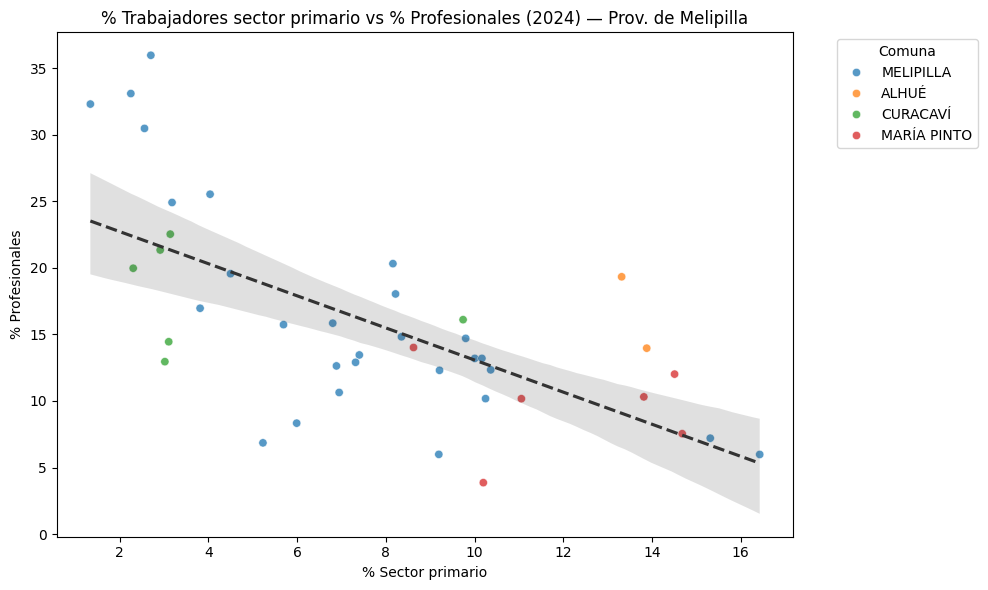

In [58]:
ig, ax = plt.subplots(figsize=(10, 6))

# 1. Scatterplot (puntos) con las variables del 2024 y COMUNA
sns.scatterplot(data=gdf_mel_2024, x='sector_primario2', y='porcentaje_profesionales2',
                hue='COMUNA', alpha=0.75, ax=ax)

# 2. Regplot (línea de tendencia) con las variables del 2024
sns.regplot(data=gdf_mel_2024, x='sector_primario2', y='porcentaje_profesionales2',
            scatter=False, color='#333', line_kws={'ls': '--'}, ax=ax)

# 3. Textos y etiquetas actualizados al 2024
ax.set(xlabel='% Sector primario', ylabel='% Profesionales',
       title='% Trabajadores sector primario vs % Profesionales (2024) — Prov. de Melipilla')

# Mueve la leyenda de las comunas afuera del gráfico para que no tape los datos
plt.legend(title='Comuna', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()